# LSTM Text Sequence Classification with Learned and Pretrained Embeddings

This notebook applies recurrent sequence modeling to text paragraphs from four Project Gutenberg books.

The progression is:

```text
raw paragraphs
→ train / validation / test split
→ tokenization
→ training vocabulary
→ integer sequences
→ padding / truncation
→ learned embeddings
→ LSTM text classification
→ pretrained GloVe embeddings
→ trainable vs. frozen/fine-tuned embeddings
```

The task is to predict which book a paragraph came from.


## Why Use an LSTM for Text?

A paragraph is an ordered sequence of words. A bag-of-words representation can record which words appear, but it does not preserve the complete word order.

An LSTM processes the paragraph one token at a time and carries information through the sequence. Its gates learn which information should be retained, updated, or forgotten.

For this task, the LSTM can learn patterns such as:

- which words and phrases are characteristic of each book,
- how neighboring and earlier words contribute to the paragraph representation,
- and how the final sequence representation maps to one of the four book classes.


## Import Libraries


In [ ]:
import bs4 as bs
import urllib.request
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from tensorflow.keras.optimizers import *

from keras.models import Model
from keras.regularizers import l2

from tensorflow.keras.preprocessing.text import Tokenizer

from keras.utils import pad_sequences
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback, LearningRateScheduler


## Training Curves and Best-Metric Summary


In [ ]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'validation')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[0].grid(True)
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'validation')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  ax[1].grid(True)
  plt.show()

def print_best_metrics(h):
  labels = ['training accuracy', 'validation accuracy', 'training loss', 'validation loss']
  keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
  prefix = ['highest','lowest']
  for i in range(4):
    metric = np.array(h[keys[i]])
    am = np.argmax((1.5-i)*metric)
    print(f'The {prefix[i//2]} {labels[i]} was {metric[am]:.4f} obtained in epoch {am+1}')
    print(f'The final {labels[i]} was {metric[-1]:.4f}')


## Download the Four Books

The dataset contains paragraphs from:

- *The Call of the Wild* by Jack London
- *Dracula* by Bram Stoker
- *The Adventures of Sherlock Holmes* by Arthur Conan Doyle
- *Twenty Thousand Leagues under the Sea* by Jules Verne


In [ ]:
def get_paragraph_list(url,skip):
    paragraphs = []
    data = urllib.request.urlopen(url).read()
    soup = bs.BeautifulSoup(data,'lxml')
    for paragraph in soup.find_all('p'):
        par  = paragraph.get_text()
        if par:
            if len(par)>=30:
              paragraphs.append(par)
    return paragraphs[skip:]

books = [215,345,1661,164]
url_list = [f'http://www.gutenberg.org/files/{i}/{i}-h/{i}-h.htm' for  i in books]

paragraphs = []
targets = []
first_par = []
skip = [1,5,1,0]
for u, url in enumerate(url_list):
    par = get_paragraph_list(url,skip[u])
    paragraphs = paragraphs + par
    targets = targets + [u for i in par]
    print('\nBook {} contains {} paragraphs'.format(u,len(par)))
    lengths = np.array([len(wl) for wl in par])
    print('Paragraph length stats:')
    print('min = {} max = {} mean = {:4f}'.format(np.min(lengths),np.max(lengths),np.mean(lengths)))
    print('First paragraph:')
    print(par[0])

targets = np.array(targets)


Book 0 contains 327 paragraphs
Paragraph length stats:
min = 43 max = 1558 mean = 534.504587
First paragraph:

Buck did not read the newspapers, or he would have known that trouble was
brewing, not alone for himself, but for every tide-water dog, strong of muscle
and with warm, long hair, from Puget Sound to San Diego. Because men, groping
in the Arctic darkness, had found a yellow metal, and because steamship and
transportation companies were booming the find, thousands of men were rushing
into the Northland. These men wanted dogs, and the dogs they wanted were heavy
dogs, with strong muscles by which to toil, and furry coats to protect them
from the frost.


Book 1 contains 1744 paragraphs
Paragraph length stats:
min = 30 max = 4713 mean = 473.360665
First paragraph:
We left in pretty good time, and came after nightfall to Klausenburgh.
Here I stopped for the night at the Hotel Royale. I had for dinner, or
rather supper, a chicken done up some way with red pepper, which was
very goo

## Split Raw Paragraphs Before Building the Vocabulary

The vocabulary must be learned from training text only. The raw paragraphs are therefore split before tokenization and vocabulary construction.

A validation split is also created from the training portion so that the final test set is used only for final model evaluation.


In [ ]:
x_train_text, x_test_text, y_train, y_test = train_test_split(
    paragraphs, targets, test_size=0.2, random_state=42, stratify=targets
)

x_train_text, x_val_text, y_train, y_val = train_test_split(
    x_train_text, y_train, test_size=0.2, random_state=42, stratify=y_train
)

print('Training paragraphs:',len(x_train_text))
print('Validation paragraphs:',len(x_val_text))
print('Test paragraphs:',len(x_test_text))


Training paragraphs: 4028
Validation paragraphs: 1007
Test paragraphs: 1259


## Inspect a Random Training Paragraph


In [ ]:
p = np.random.randint(0,len(x_train_text))
print(x_train_text[p])



Buck did not attack, but circled him about and hedged him in with friendly
advances. The wolf was suspicious and afraid; for Buck made three of him in
weight, while his head barely reached Buck’s shoulder. Watching his
chance, he darted away, and the chase was resumed. Time and again he was
cornered, and the thing repeated, though he was in poor condition, or Buck
could not so easily have overtaken him. He would run till Buck’s head was
even with his flank, when he would whirl around at bay, only to dash away again
at the first opportunity.



## Tokenization

`wordpunct_tokenize` converts each paragraph into a sequence of tokens. The vocabulary is then constructed from the training tokens only.


In [ ]:
from nltk.tokenize import wordpunct_tokenize

p_tok_train = [wordpunct_tokenize(p) for p in x_train_text]
p_tok_val = [wordpunct_tokenize(p) for p in x_val_text]
p_tok_test = [wordpunct_tokenize(p) for p in x_test_text]


### Inspect the First Tokenized Training Paragraph


In [ ]:
print(p_tok_train[0])


['“', 'It', 'is', 'the', 'forest', 'of', 'the', 'Island', 'of', 'Crespo', ',”', 'thought', 'I', ';—', 'and', 'I', 'was', 'not', 'mistaken', '.']


## Build the Training Vocabulary and Integer Index

`UNKNOWN` is assigned index 0. Words not found in the training vocabulary are mapped to this index.

All paragraph sequences use a fixed length of 128. Shorter sequences are left-padded with zeros and longer sequences are truncated to the first 128 tokens.


In [ ]:
count = {}

for p in p_tok_train:
  for w in p:
    w = w.lower()
    count[w] = count.get(w,0)+1

vocabulary = list(count.keys())
frequencies = list(count.values())
vocabulary = ['UNKNOWN'] + [vocabulary[i] for i in np.argsort(frequencies)][::-1]

max_len = 128

index = {}
for i,w in enumerate(vocabulary):
  index[w] = i

print(len(vocabulary))
max_words = len(vocabulary)


14470


### Inspect Frequent and Rare Vocabulary Terms


In [ ]:
print(vocabulary[:20])
print(vocabulary[-20:])


['UNKNOWN', ',', 'the', '.', 'and', 'of', 'to', 'i', 'a', 'in', 'it', 'that', 'he', 'was', '“', 'his', 'you', 'with', 'as', 'is']
['haze', 'interposed', 'gingerly', 'walled', 'controlling', 'subduing', 'restraining', 'inciting', 'loosened', 'lull', 'retains', 'atom', 'pedestal', 'talkin', 'tags', 'buckles', 'inscrutable', 'looted', 'wherefore', 'sledded']


### Inspect Selected Word Indices


In [ ]:
for word in ['buck','dog','holmes','watson','nemo','submarine']:
  print(f'{word:10s}: {index.get(word,0)}')


buck      : 155
dog       : 352
holmes    : 133
watson    : 543
nemo      : 149
submarine : 620


## Convert Paragraphs to Integer Sequences

The same training vocabulary is used for training, validation, and test paragraphs. Words that were not seen in the training vocabulary are mapped to index 0.


In [ ]:
def paragraphs_to_sequences(tokenized_paragraphs,index,max_len=128):
  seq_arr = np.zeros((len(tokenized_paragraphs),max_len),dtype=int)

  for i,p in enumerate(tokenized_paragraphs):
    ind_seq = []
    for w in p[:max_len]:
      ind_seq.append(index.get(w.lower(),0))

    if len(ind_seq)>0:
      seq_arr[i,-len(ind_seq):] = ind_seq

  return seq_arr

x_train = paragraphs_to_sequences(p_tok_train,index,max_len)
x_val = paragraphs_to_sequences(p_tok_val,index,max_len)
x_test = paragraphs_to_sequences(p_tok_test,index,max_len)

print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
print(x_test.shape)
print(y_test.shape)


(4028, 128)
(4028,)
(1007, 128)
(1007,)
(1259, 128)
(1259,)


### Inspect One Integer Sequence


In [ ]:
x_train[0]


array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,   14,   10,
         19,    2,  811,    5,    2,  428,    5, 2736,   53,  181,    7,
       6090,    4,    7,   13,   21, 1128,    3])

### Decode a Random Training Sequence


In [ ]:
r = np.random.randint(len(x_train))
print(x_train[r])

print('\nDecoded paragraph:')
for i in x_train[r]:
  if i>0:
    print(vocabulary[i],end = ' ')


[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    8 1670 1195  248  496    2   97   27   45  483    1    4   11   13
   37    3]

Decoded paragraph:
a ghastly smile passed across the captain ’ s lips , and that was all . 

Words that do not occur in the training vocabulary are represented by index 0. The same index is also used for left padding in this source-style sequence representation.


# 1. Baseline LSTM with Learned Embeddings

The embedding layer starts with randomly initialized word vectors. During training, both the embedding vectors and the LSTM/classification weights are learned from the paragraph-classification objective.

The model therefore learns:

1. a dense vector representation for each training-vocabulary word,
2. sequential patterns through the LSTM,
3. the mapping from the final LSTM representation to the four book classes.


Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 481ms/step - accuracy: 0.3625 - loss: 1.2676 - val_accuracy: 0.3515 - val_loss: 1.2056
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 450ms/step - accuracy: 0.4762 - loss: 1.1507 - val_accuracy: 0.5353 - val_loss: 1.0902
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 434ms/step - accuracy: 0.6020 - loss: 0.9701 - val_accuracy: 0.6713 - val_loss: 0.8217
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 434ms/step - accuracy: 0.7048 - loss: 0.7477 - val_accuracy: 0.7279 - val_loss: 0.6895
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 447ms/step - accuracy: 0.8086 - loss: 0.5317 - val_accuracy: 0.8044 - val_loss: 0.5367
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 435ms/step - accuracy: 0.8652 - loss: 0.3903 - val_accuracy: 0.8242 - val_loss: 0.4556
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 455ms/step - accuracy: 0.8960 - loss: 0.3025 - val_accuracy: 0.8272 - val_loss: 0.4633
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 459ms/step - accuracy: 0.9208 - loss: 0.2513 - 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 128, 50)        │       723,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,352,914 (8.98 MB)

 Trainable params: 784,304 (2.99 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,568,610 (5.98 MB)

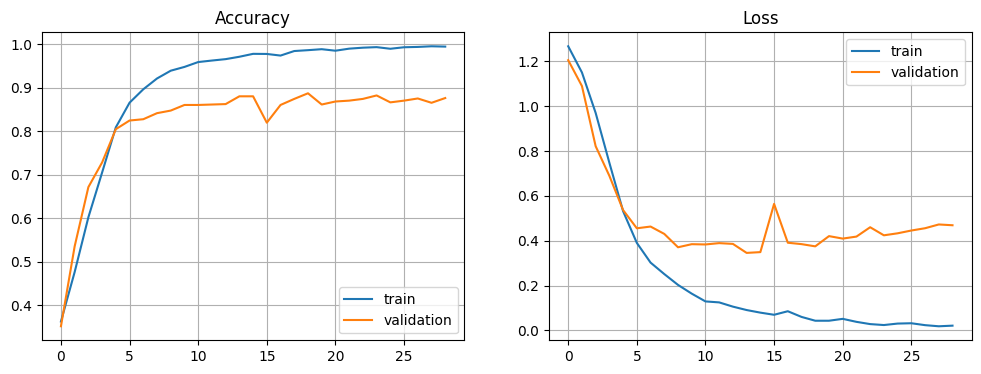

The highest training accuracy was 0.9948 obtained in epoch 28
The final training accuracy was 0.9940
The highest validation accuracy was 0.8868 obtained in epoch 19
The final validation accuracy was 0.8759
The lowest training loss was 0.0184 obtained in epoch 28
The final training loss was 0.0212
The lowest validation loss was 0.3458 obtained in epoch 14
The final validation loss was 0.4691
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
Test confusion matrix:
[[ 46   6   4   9]
 [  0 296  37  16]
 [  2  22 381  21]
 [  0   5  18 396]]
Test accuracy: 0.888801


In [ ]:
def recurrent_net(vocab_size,emb_len=100, seq_len=128, n_classes=4,dropout=0.5,n=128):
  model = tf.keras.models.Sequential()
  model.add(Embedding(vocab_size,emb_len))
  model.add(Dropout(dropout))
  model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
  model.add(Dense(n_classes,activation= 'softmax'))
  return model

earlystopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

model = recurrent_net(vocab_size=max_words, emb_len=50, n=128)
model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=100,
    verbose=1,
    batch_size=128,
    callbacks=[earlystopping]
)

model.summary()
plot_results(history)
print_best_metrics(history.history)

pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Test confusion matrix:')
print(confusion_matrix(y_test,pred_class))
print(f'Test accuracy:{accuracy_score(y_test,pred_class):9.6f}')


# 2. Pretrained GloVe Embeddings

The next experiments initialize the embedding layer with GloVe vectors. GloVe embeddings are learned from large-scale word co-occurrence statistics and provide semantic information before the book-classification model is trained.

The source experiments compare multiple GloVe dimensions and LSTM/training configurations.


## Download GloVe


In [ ]:
!wget -nc http://nlp.stanford.edu/data/glove.6B.zip
!unzip -o -q glove.6B.zip


--2026-09-09 05:52:19--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-09-09 05:52:19--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-09-09 05:52:20--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

## Read 50d, 100d, and 200d GloVe Embeddings


In [ ]:
import numpy as np

def read_embeddings(size=100):
    # Reads n embeddings from file
    # Returns a dictionary where embedding[w] is the embeding of string w
    embedding = {}
    with open(f'glove.6B.{size}d.txt', encoding="utf8") as f:
        for line in f:
            ls = line.split(" ")
            emb = np.array([np.float32(x) for x in ls[1:]])
            embedding[ls[0]]=emb
    return embedding

embedding_50 = read_embeddings(50)
embedding_100 = read_embeddings(100)
embedding_200 = read_embeddings(200)

### Check the Number of 50-Dimensional Embeddings


In [ ]:
print(len(embedding_50))


400000


## Build the Embedding Matrix


In [ ]:
def find_embedding_matrix(vocabulary, embedding_dict):
  for k in embedding_dict:
    emb_len = len(embedding_dict[k])
    break
  emb_mat = np.zeros((len(vocabulary), emb_len), dtype=np.float32)
  words_in_ed = 0
  for i, w in enumerate(vocabulary):
    if w in embedding_dict:
      emb_mat[i] = embedding_dict[w]
      words_in_ed += 1
  print(words_in_ed,'words found in dictionary')
  return emb_mat

## 2.1 GloVe 50d, Trainable from the Start

The embedding layer is initialized with 50-dimensional GloVe vectors. Because `trainable=False` is not specified, the pretrained embeddings are updated together with the LSTM during training.


13723 words found in dictionary
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 535ms/step - accuracy: 0.4136 - loss: 1.2220 - val_accuracy: 0.4856 - val_loss: 1.1052
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 484ms/step - accuracy: 0.5206 - loss: 1.0679 - val_accuracy: 0.6087 - val_loss: 0.9481
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 568ms/step - accuracy: 0.5896 - loss: 0.9903 - val_accuracy: 0.6514 - val_loss: 0.8875
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 487ms/step - accuracy: 0.6254 - loss: 0.9208 - val_accuracy: 0.6882 - val_loss: 0.7882
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 493ms/step - accuracy: 0.6594 - loss: 0.8374 - val_accuracy: 0.6971 - val_loss: 0.7564
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 473ms/step - accuracy: 0.6869 - loss: 0.7669 - val_accuracy: 0.7249 - val_loss: 0.6943
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 515ms/step - accuracy: 0.7123 - loss: 0.7324 - val_accuracy: 0.7488 - val_loss: 0.6284
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 664ms/step - ac

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 128, 50)        │       723,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,352,914 (8.98 MB)

 Trainable params: 784,304 (2.99 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,568,610 (5.98 MB)

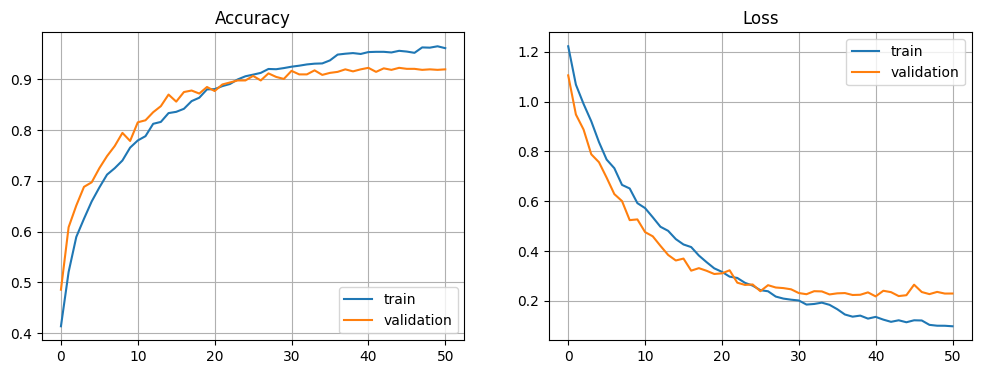

The highest training accuracy was 0.9650 obtained in epoch 50
The final training accuracy was 0.9613
The highest validation accuracy was 0.9225 obtained in epoch 41
The final validation accuracy was 0.9196
The lowest training loss was 0.0976 obtained in epoch 51
The final training loss was 0.0976
The lowest validation loss was 0.2177 obtained in epoch 41
The final validation loss was 0.2291
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step
Test confusion matrix:
[[ 57   5   2   1]
 [  1 318  19  11]
 [  0  26 386  14]
 [  2   9   8 400]]
Test accuracy: 0.922160


In [ ]:
def recurrent_net(embedding_matrix,n_classes=4,dropout=0.5,n=128):
  model = tf.keras.models.Sequential()

  embedding_layer = Embedding(
    input_dim=embedding_matrix.shape[0],
    output_dim=embedding_matrix.shape[1],
    weights=[embedding_matrix]
  )

  model.add(embedding_layer)
  model.add(Dropout(dropout))
  model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
  model.add(Dense(n_classes,activation='softmax'))
  return model

earlystopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

emb_mat = find_embedding_matrix(vocabulary,embedding_50)
model = recurrent_net(emb_mat,n=128)

model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    x_train,y_train,
    validation_data=(x_val,y_val),
    epochs=100,
    verbose=1,
    batch_size=128,
    callbacks=[earlystopping]
)

model.summary()
plot_results(history)
print_best_metrics(history.history)

pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Test confusion matrix:')
print(confusion_matrix(y_test,pred_class))
print(f'Test accuracy:{accuracy_score(y_test,pred_class):9.6f}')


## 2.2 GloVe 200d with a Smaller LSTM and Larger Batch

This distinct configuration uses 200-dimensional pretrained embeddings, an LSTM with 50 units, recurrent dropout of 0.5, and a batch size of 1024.


13723 words found in dictionary
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.3312 - loss: 1.3456 - val_accuracy: 0.3883 - val_loss: 1.2230
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.4228 - loss: 1.2250 - val_accuracy: 0.5263 - val_loss: 1.1778
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.4791 - loss: 1.1826 - val_accuracy: 0.5392 - val_loss: 1.1525
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - accuracy: 0.5169 - loss: 1.1535 - val_accuracy: 0.5541 - val_loss: 1.1182
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.5367 - loss: 1.1159 - val_accuracy: 0.5660 - val_loss: 1.0749
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 3s/step - accuracy: 0.5598 - loss: 1.0742 - val_accuracy: 0.5919 - val_loss: 1.0295
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.5772 - loss: 1.0381 - val_accuracy: 0.6127 - val_loss: 0.9851
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 13s 3s/step - accuracy: 0.5919 - loss: 1.0045 - val_accu

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 128, 200)       │     2,894,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128, 200)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        50,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           204 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833,214 (33.70 MB)

 Trainable params: 2,944,404 (11.23 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,888,810 (22.46 MB)

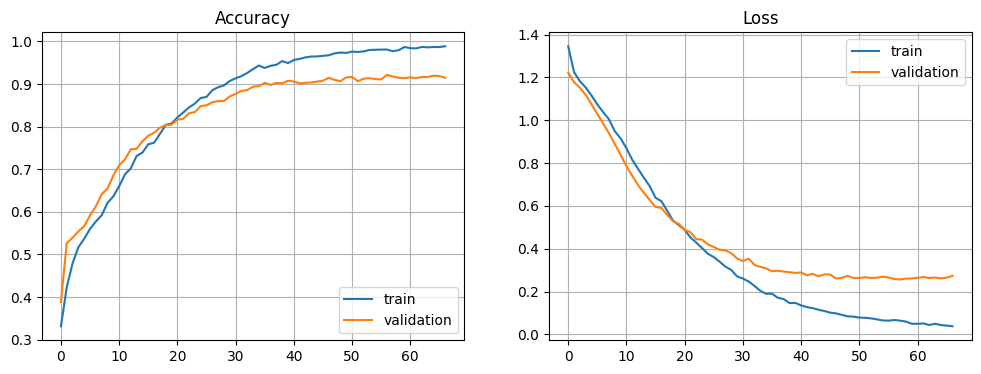

The highest training accuracy was 0.9886 obtained in epoch 67
The final training accuracy was 0.9886
The highest validation accuracy was 0.9215 obtained in epoch 57
The final validation accuracy was 0.9146
The lowest training loss was 0.0380 obtained in epoch 67
The final training loss was 0.0380
The lowest validation loss was 0.2563 obtained in epoch 58
The final validation loss was 0.2739
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step
Test confusion matrix:
[[ 56   3   4   2]
 [  1 303  31  14]
 [  0  12 401  13]
 [  0   8  12 399]]
Test accuracy: 0.920572


In [ ]:
def recurrent_net(embedding_matrix,n_classes=4,dropout=0.5,n=128):
  model = tf.keras.models.Sequential()

  embedding_layer = Embedding(
    input_dim=embedding_matrix.shape[0],
    output_dim=embedding_matrix.shape[1],
    weights=[embedding_matrix]
  )

  model.add(embedding_layer)
  model.add(Dropout(dropout))
  model.add(LSTM(50,recurrent_dropout=0.5))
  model.add(Dense(n_classes,activation='softmax'))
  return model

earlystopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

emb_mat = find_embedding_matrix(vocabulary,embedding_200)
model = recurrent_net(emb_mat,n=128)

model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    x_train,y_train,
    validation_data=(x_val,y_val),
    epochs=100,
    verbose=1,
    batch_size=1024,
    callbacks=[earlystopping]
)

model.summary()
plot_results(history)
print_best_metrics(history.history)

pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Test confusion matrix:')
print(confusion_matrix(y_test,pred_class))
print(f'Test accuracy:{accuracy_score(y_test,pred_class):9.6f}')


## 2.3 GloVe 100d, Trainable from the Start

This configuration uses 100-dimensional GloVe embeddings with the 100-unit LSTM architecture.


13723 words found in dictionary
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 585ms/step - accuracy: 0.4332 - loss: 1.1975 - val_accuracy: 0.5144 - val_loss: 1.1123
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 552ms/step - accuracy: 0.5425 - loss: 1.0528 - val_accuracy: 0.6405 - val_loss: 0.8973
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 561ms/step - accuracy: 0.6187 - loss: 0.9151 - val_accuracy: 0.7041 - val_loss: 0.7794
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 572ms/step - accuracy: 0.6576 - loss: 0.8464 - val_accuracy: 0.7289 - val_loss: 0.7143
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 563ms/step - accuracy: 0.7051 - loss: 0.7492 - val_accuracy: 0.7498 - val_loss: 0.6217
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 562ms/step - accuracy: 0.7344 - loss: 0.6523 - val_accuracy: 0.7895 - val_loss: 0.5240
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 592ms/step - accuracy: 0.7642 - loss: 0.5860 - val_accuracy: 0.8123 - val_loss: 0.4820
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 647ms/step - ac

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 128, 100)       │     1,447,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583,414 (17.48 MB)

 Trainable params: 1,527,804 (5.83 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,055,610 (11.66 MB)

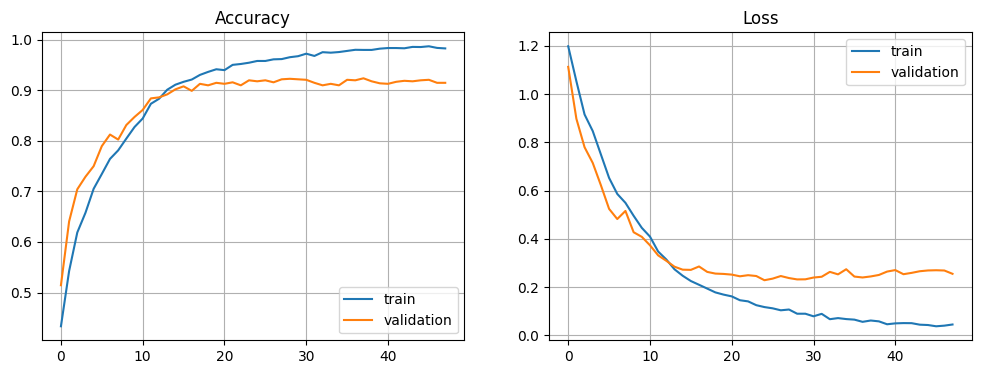

The highest training accuracy was 0.9868 obtained in epoch 46
The final training accuracy was 0.9826
The highest validation accuracy was 0.9235 obtained in epoch 38
The final validation accuracy was 0.9146
The lowest training loss was 0.0377 obtained in epoch 46
The final training loss was 0.0451
The lowest validation loss was 0.2285 obtained in epoch 25
The final validation loss was 0.2550
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step
Test confusion matrix:
[[ 59   2   4   0]
 [  1 316  21  11]
 [  1  12 406   7]
 [  0  12  12 395]]
Test accuracy: 0.934075


In [ ]:
def recurrent_net(embedding_matrix,n_classes=4,dropout=0.5,n=128):
  model = tf.keras.models.Sequential()

  embedding_layer = Embedding(
    input_dim=embedding_matrix.shape[0],
    output_dim=embedding_matrix.shape[1],
    weights=[embedding_matrix]
  )

  model.add(embedding_layer)
  model.add(Dropout(dropout))
  model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
  model.add(Dense(n_classes,activation='softmax'))
  return model

earlystopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

emb_mat = find_embedding_matrix(vocabulary,embedding_100)
model = recurrent_net(emb_mat,n=128)

model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history = model.fit(
    x_train,y_train,
    validation_data=(x_val,y_val),
    epochs=100,
    verbose=1,
    batch_size=128,
    callbacks=[earlystopping]
)

model.summary()
plot_results(history)
print_best_metrics(history.history)

pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print('Test confusion matrix:')
print(confusion_matrix(y_test,pred_class))
print(f'Test accuracy:{accuracy_score(y_test,pred_class):9.6f}')


# 3. Two-Stage GloVe LSTM Training

The embedding layer is first frozen so that the LSTM learns while preserving the original GloVe vectors. The embedding layer is then unfrozen and fine-tuned for additional epochs.

This directly tests whether limited task-specific modification of pretrained embeddings improves the paragraph classifier.


13723 words found in dictionary

--- Stage 1: Training with frozen embeddings ---
Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 23s 483ms/step - accuracy: 0.4131 - loss: 1.2254 - val_accuracy: 0.4975 - val_loss: 1.1385
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 467ms/step - accuracy: 0.5072 - loss: 1.1078 - val_accuracy: 0.5641 - val_loss: 1.0470
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 478ms/step - accuracy: 0.5504 - loss: 1.0196 - val_accuracy: 0.6286 - val_loss: 0.9160
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 540ms/step - accuracy: 0.5896 - loss: 0.9634 - val_accuracy: 0.6634 - val_loss: 0.8672
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 512ms/step - accuracy: 0.6025 - loss: 0.9218 - val_accuracy: 0.6703 - val_loss: 0.8185
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 453ms/step - accuracy: 0.6189 - loss: 0.8925 - val_accuracy: 0.6753 - val_loss: 0.8013
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 480ms/step - accuracy: 0.6311 - loss: 0.8594 - val_accuracy: 0.6912 - val_loss: 0.7766
Epoch 8/20
32/3

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 128, 100)       │     1,447,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128, 100)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           404 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583,414 (17.48 MB)

 Trainable params: 1,527,804 (5.83 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,055,610 (11.66 MB)

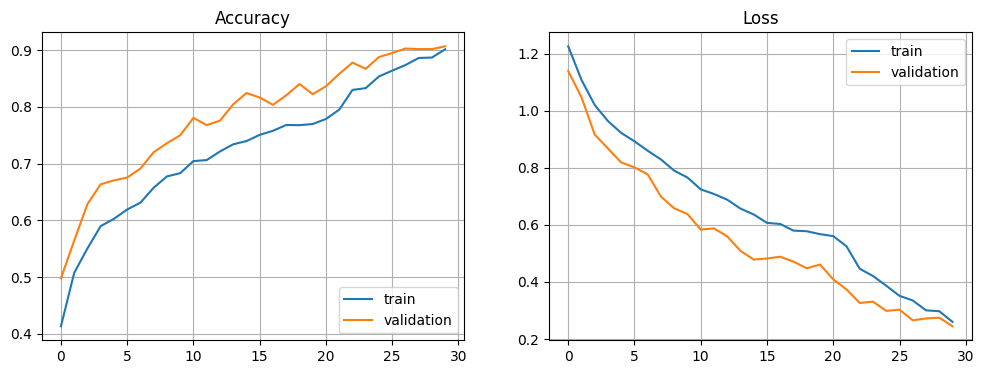

The highest training accuracy was 0.9014 obtained in epoch 30
The final training accuracy was 0.9014
The highest validation accuracy was 0.9067 obtained in epoch 30
The final validation accuracy was 0.9067
The lowest training loss was 0.2600 obtained in epoch 30
The final training loss was 0.2600
The lowest validation loss was 0.2446 obtained in epoch 30
The final validation loss was 0.2446

Fine-tuned test performance:
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step
[[ 58   2   5   0]
 [  3 287  44  15]
 [  2  14 405   5]
 [  0  12  19 388]]
Test accuracy: 0.903892


In [ ]:
def recurrent_net_two_stage(embedding_matrix,n_classes=4,dropout=0.5,n=128):
  model = tf.keras.models.Sequential()

  embedding_layer = Embedding(
    input_dim=embedding_matrix.shape[0],
    output_dim=embedding_matrix.shape[1],
    weights=[embedding_matrix],
    trainable=False
  )

  model.add(embedding_layer)
  model.add(Dropout(dropout))
  model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
  model.add(Dense(n_classes,activation='softmax'))
  return model

earlystopping = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

emb_mat = find_embedding_matrix(vocabulary,embedding_100)

model = recurrent_net_two_stage(emb_mat,n=128)
model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

print('\n--- Stage 1: Training with frozen embeddings ---')
history_stage1 = model.fit(
    x_train,y_train,
    validation_data=(x_val,y_val),
    epochs=20,
    verbose=1,
    batch_size=128,
    callbacks=[earlystopping]
)

print('\nFrozen-embedding test performance:')
pred_frozen = model.predict(x_test)
pred_frozen_class = np.argmax(pred_frozen,axis=1)
print(confusion_matrix(y_test,pred_frozen_class))
print(f'Test accuracy:{accuracy_score(y_test,pred_frozen_class):9.6f}')

print('\n--- Stage 2: Fine-tuning with unfrozen embeddings ---')
model.layers[0].trainable = True
model.compile(optimizer=AdamW(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history_stage2 = model.fit(
    x_train,y_train,
    validation_data=(x_val,y_val),
    epochs=10,
    verbose=1,
    batch_size=128,
    callbacks=[earlystopping]
)

combined_history = {}
for key in history_stage1.history.keys():
  combined_history[key] = history_stage1.history[key] + history_stage2.history[key]

class HistoryWrapper:
  def __init__(self,history):
    self.history = history

model.summary()
plot_results(HistoryWrapper(combined_history))
print_best_metrics(combined_history)

print('\nFine-tuned test performance:')
pred = model.predict(x_test)
pred_class = np.argmax(pred,axis=1)
print(confusion_matrix(y_test,pred_class))
print(f'Test accuracy:{accuracy_score(y_test,pred_class):9.6f}')


# Reference Results from the Supplied Experimental Runs

The supplied runs recorded the following results for the distinct LSTM configurations:

| Configuration | Best reported validation accuracy | Lowest reported validation loss | Reported final accuracy |
|---|---:|---:|---:|
| Learned 50d embeddings + LSTM(100) | 0.9134 | 0.2908 | 0.913423 |
| GloVe 50d + LSTM(100) | 0.9333 | 0.2158 | 0.933280 |
| GloVe 200d + LSTM(50), batch 1024 | 0.9174 | 0.2570 | 0.917395 |
| GloVe 100d + LSTM(100), trainable from start | **0.9396** | **0.2060** | **0.939635** |
| GloVe 100d, frozen then fine-tuned | 0.8944 | 0.2658 | 0.894361 |

Those runs used the held-out split as validation data during model fitting. The portfolio implementation above separates training, validation, and test data, so the rerun test results should be used as the final unbiased comparison.


## Interpretation

Among the recorded configurations, the 100-dimensional GloVe model with embeddings trainable from the beginning achieved the highest reported accuracy. The two-stage frozen-then-unfrozen experiment did not outperform the trainable-from-start configuration in the recorded run.

After rerunning the corrected train/validation/test workflow, compare the final test accuracies again because the data-selection procedure is now stricter.


## Key Takeaways

- Text paragraphs are naturally represented as ordered integer sequences.
- The vocabulary should be learned from training text only.
- A learned embedding layer adjusts word vectors directly for the classification task.
- GloVe provides pretrained semantic vectors learned from a much larger corpus.
- An LSTM learns dependencies across the ordered word sequence.
- Pretrained embeddings can be trainable immediately, kept frozen, or fine-tuned after an initial frozen stage.
- A separate validation set should guide early stopping; the test set should be reserved for final evaluation.
